In [19]:
# ============================================================
#  Imports e setup de pastas
# ============================================================
import os
import zipfile

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer

# Cria a estrutura de pastas do projeto (idempotente - não dá erro se já existir)
for pasta in ['data', 'notebooks', 'outputs']:
    os.makedirs(pasta, exist_ok=True)

In [20]:
# ============================================================
# Autenticação no Kaggle
# ============================================================
from google.colab import userdata

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(userdata.get('KAGGLE_KEY'))
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)

get_ipython().system('pip install -q kaggle')
get_ipython().system('kaggle competitions list')


ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [21]:
# ============================================================
# Download e extração dos dados
# ============================================================
get_ipython().system('kaggle competitions download -c porto-seguro-safe-driver-prediction')

with zipfile.ZipFile('porto-seguro-safe-driver-prediction.zip', 'r') as z:
    z.extractall('data/')

get_ipython().system('ls data/')  # deve mostrar train.csv, test.csv, sample_submission.csv


porto-seguro-safe-driver-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)
sample_submission.csv  test.csv  train.csv


Formato do dataset: (595212, 59)

Proporção de sinistros (target):
target
0    0.963552
1    0.036448
Name: proportion, dtype: float64


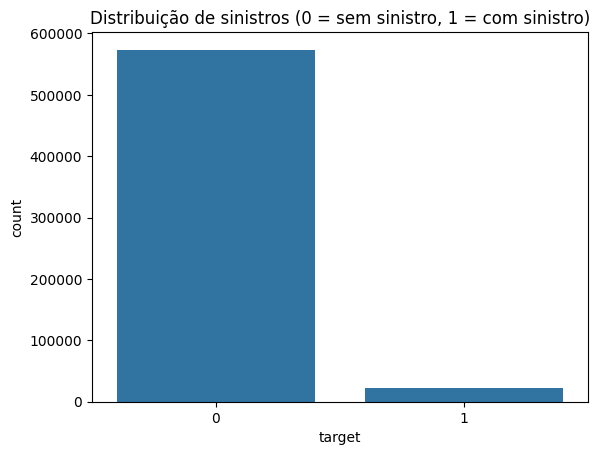

In [22]:
# ============================================================
# Exploração dos dados (EDA)
# ============================================================
df = pd.read_csv('data/train.csv')
print('Formato do dataset:', df.shape)
print('\nProporção de sinistros (target):')
print(df['target'].value_counts(normalize=True))

sns.countplot(x='target', data=df)
plt.title('Distribuição de sinistros (0 = sem sinistro, 1 = com sinistro)')
plt.show()
# Dataset desbalanceado (~3.6% de sinistros) - isso é o comportamento real do
# risco segurado, não um erro nos dados. Vou compensar isso no modelo.

In [23]:
#============================================================
# CÉLULA 5 — Pré-processamento
# ============================================================
# -1 no dataset original representa valor faltante
df = df.replace(-1, np.nan)

# Codifica variáveis categóricas em dummies (one-hot), mantendo NaN como categoria própria
cat_cols = [c for c in df.columns if c.endswith('_cat')]
df = pd.get_dummies(df, columns=cat_cols, dummy_na=True)

X = df.drop(['id', 'target'], axis=1)
y = df['target']

# Imputação: preenche valores faltantes remanescentes (colunas numéricas/ordinais)
# com a mediana de cada coluna
X = X.astype('float64')
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# stratify=y garante que a proporção rara de sinistros se mantenha igual
# no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, stratify=y, random_state=42
)


In [24]:

# ============================================================
# Modelagem: Regressão Logística (baseline)
# ============================================================
modelo_log = LogisticRegression(class_weight='balanced', max_iter=1000)
modelo_log.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [25]:
# ============================================================
# CÉLULA 7 — Modelagem: Random Forest
# ============================================================
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,          # usa todos os núcleos de CPU disponíveis - acelera o treino
    random_state=42
)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

In [26]:
# ============================================================
# CÉLULA 8 — Avaliação do modelo (AUC / Gini)
# ============================================================
probs = modelo_rf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)
gini = 2 * auc - 1
print(f'AUC: {auc:.3f} | Gini: {gini:.3f}')

# Importância das variáveis (quais fatores mais pesam no risco previsto)
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
print('\nTop 10 variáveis mais importantes:')
print(importancias.sort_values(ascending=False).head(10))

AUC: 0.628 | Gini: 0.255

Top 10 variáveis mais importantes:
ps_car_13            0.079777
ps_reg_03            0.053905
ps_ind_05_cat_0.0    0.044218
ps_reg_02            0.039741
ps_ind_17_bin        0.032841
ps_car_12            0.030391
ps_car_15            0.029358
ps_ind_03            0.027124
ps_ind_15            0.026678
ps_car_14            0.026633
dtype: float64


In [27]:
# ============================================================
# CÉLULA 9 — Segmentação de risco em decis
# ============================================================
resultado = X_test.copy()
resultado['prob_sinistro'] = probs
resultado['target_real'] = y_test.values

# Usa rank (posição ordenada) em vez do valor bruto da probabilidade -
# evita que probabilidades empatadas fiquem todas no mesmo decil
resultado['rank_prob'] = resultado['prob_sinistro'].rank(method='first')
resultado['decil_risco'] = pd.qcut(resultado['rank_prob'], 10, labels=False) + 1

tabela_decis = resultado.groupby('decil_risco').agg(
    n_segurados=('target_real', 'count'),
    taxa_sinistro_real=('target_real', 'mean'),
    prob_media_modelo=('prob_sinistro', 'mean')
).reset_index()

tabela_decis.to_excel('outputs/segmentacao_risco.xlsx', index=False)
print(tabela_decis)


   decil_risco  n_segurados  taxa_sinistro_real  prob_media_modelo
0            1        11905            0.014196           0.361419
1            2        11904            0.019825           0.395026
2            3        11904            0.025622           0.417164
3            4        11904            0.029570           0.436258
4            5        11905            0.032087           0.454159
5            6        11904            0.035114           0.471889
6            7        11904            0.039735           0.489997
7            8        11904            0.041247           0.509936
8            9        11904            0.050067           0.535639
9           10        11905            0.077026           0.586211


In [28]:
# ============================================================
# CÉLULA 10 — Baixar a tabela em Excel
# ============================================================
from google.colab import files
files.download('outputs/segmentacao_risco.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

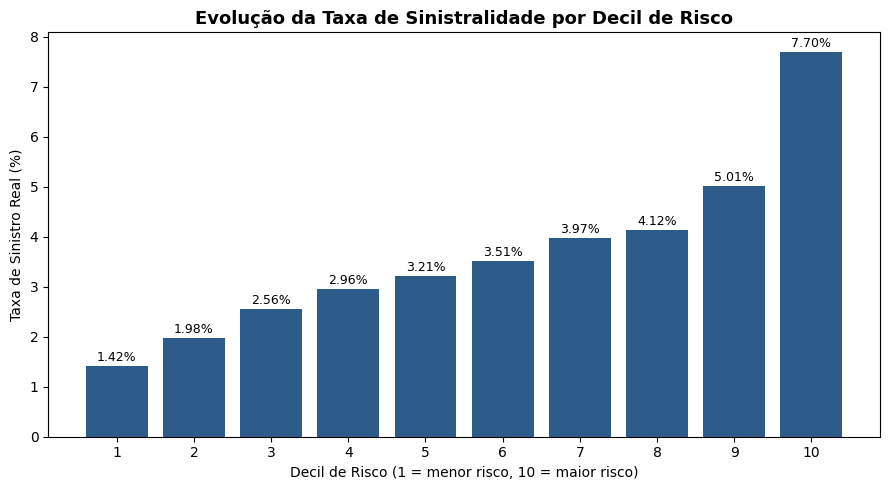

In [29]:
# ============================================================
# CÉLULA 11 — Gráfico da evolução da sinistralidade por decil
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tabela_decis['decil_risco'], tabela_decis['taxa_sinistro_real'] * 100, color='#2E5C8A')

ax.set_title('Evolução da Taxa de Sinistralidade por Decil de Risco', fontsize=13, fontweight='bold')
ax.set_xlabel('Decil de Risco (1 = menor risco, 10 = maior risco)')
ax.set_ylabel('Taxa de Sinistro Real (%)')
ax.set_xticks(tabela_decis['decil_risco'])

for i, v in enumerate(tabela_decis['taxa_sinistro_real'] * 100):
    ax.text(tabela_decis['decil_risco'].iloc[i], v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/grafico_decis_risco.png', dpi=200)
plt.show()

In [30]:
 # ============================================================
# CÉLULA 12 — Baixar o gráfico
# ============================================================
files.download('outputs/grafico_decis_risco.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>